In [1]:
import os

Sampling Rate: 22050
Audio Length (samples): 32256
Duration (sec): 1.4628571428571429


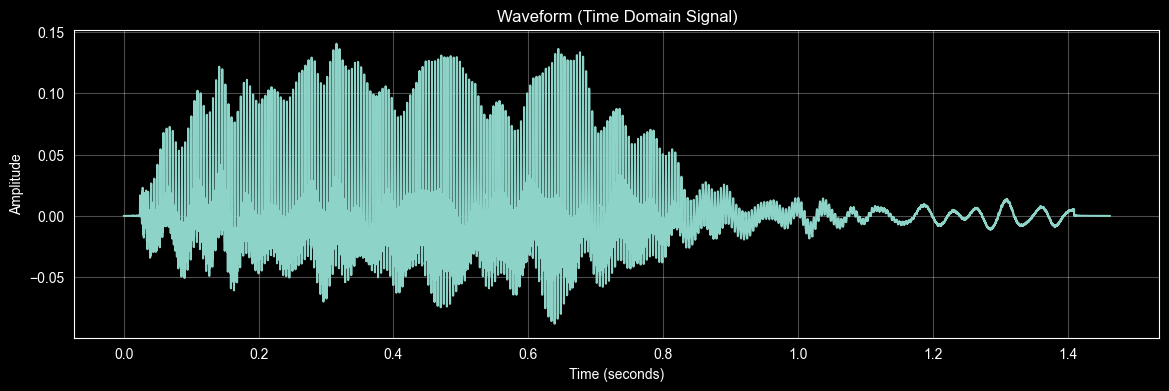

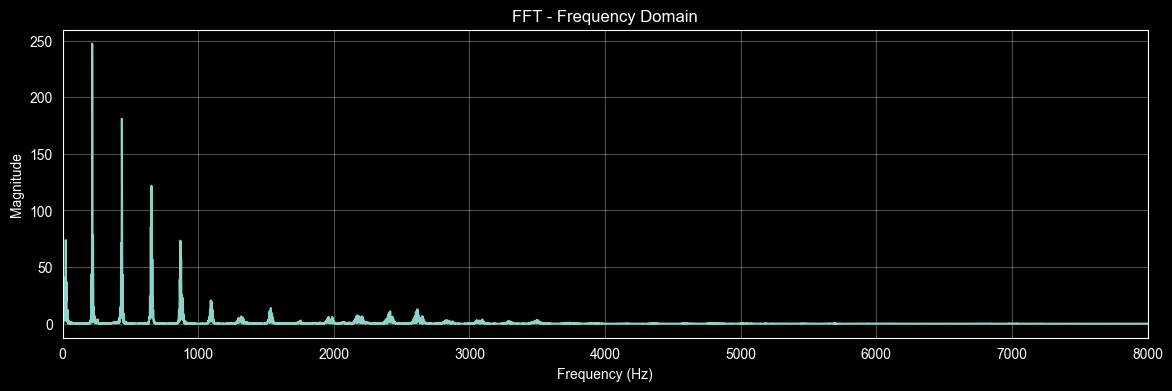

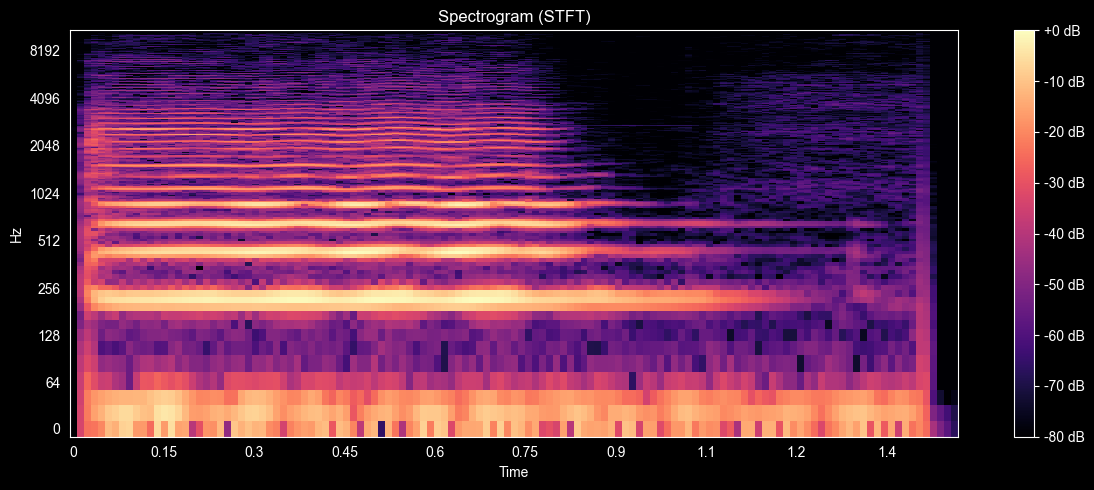


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석 


In [3]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================


import numpy as np

import matplotlib.pyplot as plt
import librosa
import librosa.display


# ============================================================
# 2. 분석할 오디오 파일 경로 설정
# ============================================================

file_path = "test.mp3"


# ============================================================
# 3. 오디오 로드
# ============================================================

y, sr = librosa.load(file_path, sr=22050)

# 오디오 길이(초)를 계산
duration = len(y) / sr

# 결과를 출력
print("Sampling Rate:", sr)
print("Audio Length (samples):", len(y))
print("Duration (sec):", duration)


# ============================================================
# 4. Waveform (시간 영역 신호) 시각화
# ============================================================

# 시간 축을 생성
time = np.linspace(0, duration, len(y))

# 그림을 생성
plt.figure(figsize=(14, 4))

# waveform
plt.plot(time, y)

plt.title("Waveform (Time Domain Signal)")

plt.xlabel("Time (seconds)")

plt.ylabel("Amplitude")

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 5. FFT (주파수 영역 변환)
# ============================================================

# FFT 수행 (실수 신호 전용 rfft 사용)
fft = np.fft.rfft(y)

# FFT magnitude 계산 (복소수 → 절댓값)
fft_magnitude = np.abs(fft)

# 주파수 축 생성
freqs = np.fft.rfftfreq(len(y), d=1/sr)

# 그림을 생성
plt.figure(figsize=(14, 4))

# FFT 결과
plt.plot(freqs, fft_magnitude)

plt.title("FFT - Frequency Domain")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

# 주파수 범위를 사람이 듣는 영역 중심으로 제한 (0~8000Hz)
plt.xlim(0, 8000)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 6. STFT (시간-주파수 변환)
# ============================================================

# STFT 계산 (짧은 구간 FFT 반복)
stft = librosa.stft(y, n_fft=1024, hop_length=256)

# 복소수 결과 → magnitude
magnitude = np.abs(stft)

# dB 스케일로 변환 (시각화에 적합)
spectrogram_db = librosa.amplitude_to_db(magnitude, ref=np.max)


# ============================================================
# 7. Spectrogram 시각화
# ============================================================

plt.figure(figsize=(12, 5))

# 스펙트로그램을 표시
librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="log"   # 로그 주파수 (음악 분석 중요)
)

# 컬러바 추가
plt.colorbar(format="%+2.0f dB")

# 제목 설정
plt.title("Spectrogram (STFT)")

# 레이아웃 정리
plt.tight_layout()

# 그래프 출력
plt.show()


# ============================================================
# 8. 핵심 요약 출력
# ============================================================

print("\n===== 분석 요약 =====")
print("Waveform → 시간에 따른 진폭 변화")
print("FFT → 전체 주파수 성분 분석")
print("Spectrogram → 시간 + 주파수 동시 분석 ")